# 05 - LSTM (Enhanced) - Lag Features ile

Bu notebook'ta 3. notebook'ta oluşturulan lag feature seti LSTM modeline uygulanmaktadır.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## Veri Yükleme ve Feature Engineering

In [2]:
df = pd.read_csv("../data/raw/request_level_data.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

# Lag features
for lag in [1, 2, 3]:
    df[f"response_time_lag_{lag}"] = df["response_time_ms"].shift(lag)

# Rolling istatistikler
df["response_time_roll_mean_5"]  = df["response_time_ms"].shift(1).rolling(5).mean()
df["response_time_roll_mean_10"] = df["response_time_ms"].shift(1).rolling(10).mean()
df["response_time_roll_std_5"]   = df["response_time_ms"].shift(1).rolling(5).std()

# Endpoint encoding
le = LabelEncoder()
df["endpoint_encoded"] = le.fit_transform(df["endpoint_name"])

df = df.dropna().reset_index(drop=True)
print(f"Veri boyutu (NaN sonrası): {df.shape}")

Veri boyutu (NaN sonrası): (29199, 21)


In [3]:
features_enhanced = [
    "payload_size",
    "active_requests",
    "rps_10s",
    "requests_last_60s",
    "response_time_lag_1",
    "response_time_lag_2",
    "response_time_lag_3",
    "response_time_roll_mean_5",
    "response_time_roll_mean_10",
    "response_time_roll_std_5",
    "endpoint_encoded"
]
target = "response_time_ms"

print(f"Feature sayısı: {len(features_enhanced)}")

Feature sayısı: 11


## Ölçekleme

In [4]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

scaled_features = scaler_X.fit_transform(df[features_enhanced])
scaled_target   = scaler_y.fit_transform(df[[target]])

print("Feature shape:", scaled_features.shape)
print("Target shape:", scaled_target.shape)

Feature shape: (29199, 11)
Target shape: (29199, 1)


## Sliding Window (3D)

In [5]:
def create_window_3d(features_arr, target_arr, window_size):
    X, y = [], []
    for i in range(len(features_arr) - window_size):
        X.append(features_arr[i:i+window_size])
        y.append(target_arr[i+window_size])
    return np.array(X), np.array(y)

WINDOW_SIZE = 10
X, y = create_window_3d(scaled_features, scaled_target, WINDOW_SIZE)

print(f"X shape: {X.shape}  →  (samples, timesteps, features)")
print(f"y shape: {y.shape}")

X shape: (29189, 10, 11)  →  (samples, timesteps, features)
y shape: (29189, 1)


## Train-Test Ayrımı

In [6]:
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (23351, 10, 11), Test: (5838, 10, 11)


## LSTM Model

In [7]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, len(features_enhanced))),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()

C:\Users\bahar\source\repos\API-Analysis\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 10, 64)              │          19,456 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 10, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 32,417 (126.63 KB)

 Trainable params: 32,417 (126.63 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0042 - mae: 0.0446 - val_loss: 0.0035 - val_mae: 0.0410
Epoch 2/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0038 - mae: 0.0414 - val_loss: 0.0034 - val_mae: 0.0399
Epoch 3/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0036 - mae: 0.0396 - val_loss: 0.0032 - val_mae: 0.0364
Epoch 4/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0034 - mae: 0.0378 - val_loss: 0.0029 - val_mae: 0.0355
Epoch 5/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0033 - mae: 0.0366 - val_loss: 0.0028 - val_mae: 0.0341
Epoch 6/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0032 - mae: 0.0356 - val_loss: 0.0030 - val_mae: 0.0349
Epoch 7/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0031 - mae: 0.0348 - val_loss: 0.0027 - val_mae: 0.0323
Epoch 8/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0031 - mae: 0.0344 - val_loss: 0.0026 - val_mae: 0.0312
Epoch 9/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - l

## Eğitim Grafiği

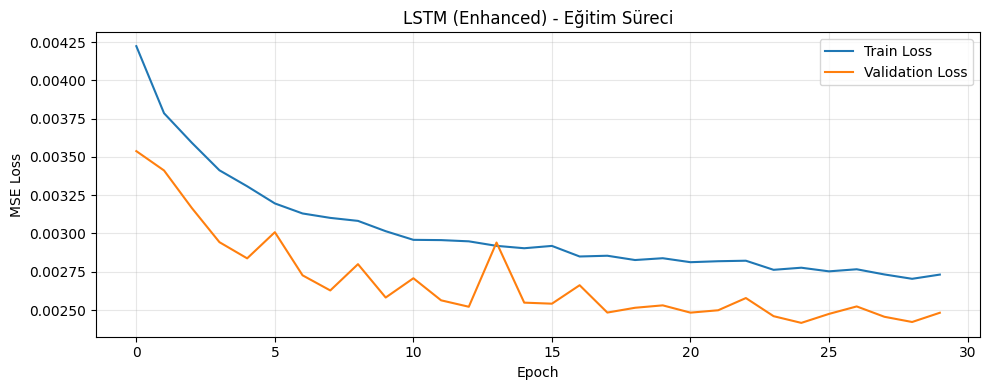

In [9]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM (Enhanced) - Eğitim Süreci')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/lstm_enhanced_training.png", dpi=150, bbox_inches='tight')
plt.show()

## Tahmin ve Performans

In [10]:
y_pred_scaled = model.predict(X_test)
y_pred_lstm   = scaler_y.inverse_transform(y_pred_scaled).flatten()
y_test_orig   = scaler_y.inverse_transform(y_test).flatten()

def evaluate(y_true, y_pred, model_name):
    return {
        "Model": model_name,
        "MAE":  round(mean_absolute_error(y_true, y_pred), 2),
        "RMSE": round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
        "R2":   round(r2_score(y_true, y_pred), 4)
    }

lstm_enh_results = evaluate(y_test_orig, y_pred_lstm, "LSTM (enhanced)")
print(lstm_enh_results)

183/183 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
{'Model': 'LSTM (enhanced)', 'MAE': 88.75, 'RMSE': np.float64(154.16), 'R2': 0.3992}


## Final Karşılaştırma Tablosu

In [11]:
all_results = [
    {"Model": "LR (baseline)",       "MAE": 147.21, "RMSE": 196.44, "R2": 0.0242},
    {"Model": "RF (baseline)",       "MAE": 146.37, "RMSE": 196.56, "R2": 0.0230},
    {"Model": "LSTM (baseline)",     "MAE": 121.23, "RMSE": 177.79, "R2": 0.2008},
    {"Model": "LR (enhanced)",       "MAE": 123.71, "RMSE": 178.91, "R2": 0.1908},
    {"Model": "RF (enhanced)",       "MAE":  88.17, "RMSE": 152.82, "R2": 0.4096},
    lstm_enh_results
]

final_df = pd.DataFrame(all_results).set_index("Model")
print(final_df.to_string())
final_df

                    MAE    RMSE      R2
Model                                  
LR (baseline)    147.21  196.44  0.0242
RF (baseline)    146.37  196.56  0.0230
LSTM (baseline)  121.23  177.79  0.2008
LR (enhanced)    123.71  178.91  0.1908
RF (enhanced)     88.17  152.82  0.4096
LSTM (enhanced)   88.75  154.16  0.3992


,MAE,RMSE,R2
Model,,,
LR (baseline),147.21,196.44,0.0242
RF (baseline),146.37,196.56,0.0230
LSTM (baseline),121.23,177.79,0.2008
LR (enhanced),123.71,178.91,0.1908
RF (enhanced),88.17,152.82,0.4096
LSTM (enhanced),88.75,154.16,0.3992


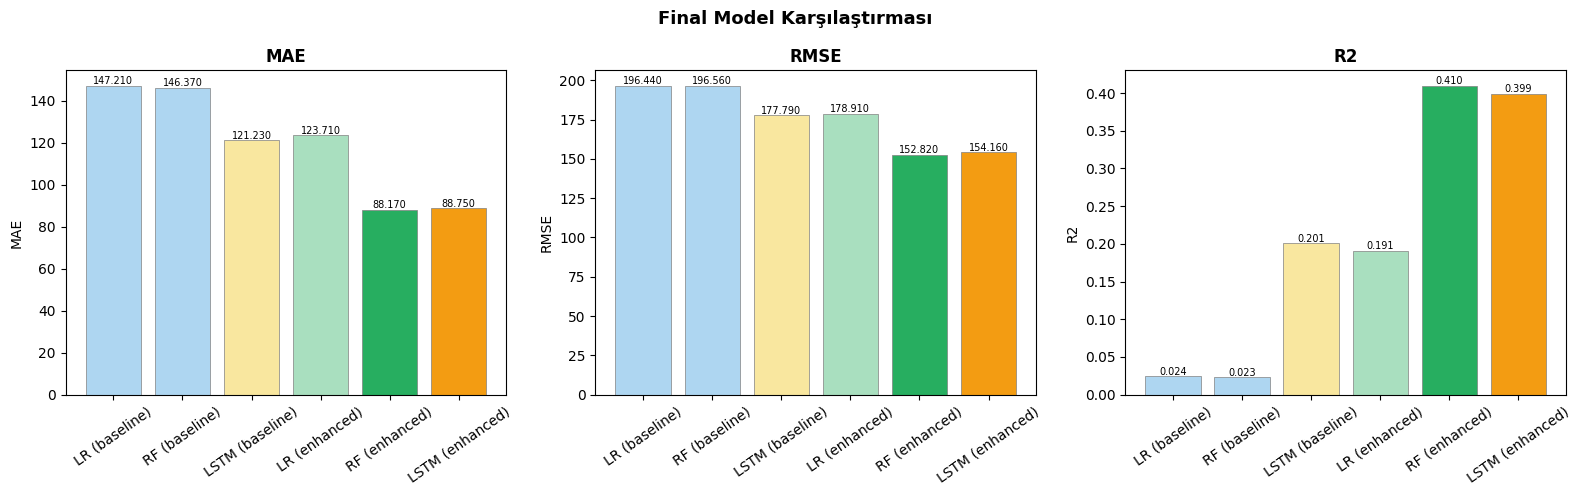

In [12]:
# Final karşılaştırma grafiği
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ["MAE", "RMSE", "R2"]

color_map = {
    "LR (baseline)":   "#aed6f1",
    "RF (baseline)":   "#aed6f1",
    "LSTM (baseline)": "#f9e79f",
    "LR (enhanced)":   "#a9dfbf",
    "RF (enhanced)":   "#27ae60",
    "LSTM (enhanced)": "#f39c12",
}

for ax, metric in zip(axes, metrics):
    vals = final_df[metric]
    colors = [color_map[m] for m in vals.index]
    bars = ax.bar(vals.index, vals.values, color=colors, edgecolor='gray', linewidth=0.5)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=35)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005 * max(vals.values),
                f"{val:.3f}", ha='center', fontsize=7)

plt.suptitle("Final Model Karşılaştırması", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("../outputs/final_model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

## Gerçek vs Tahmin Grafiği

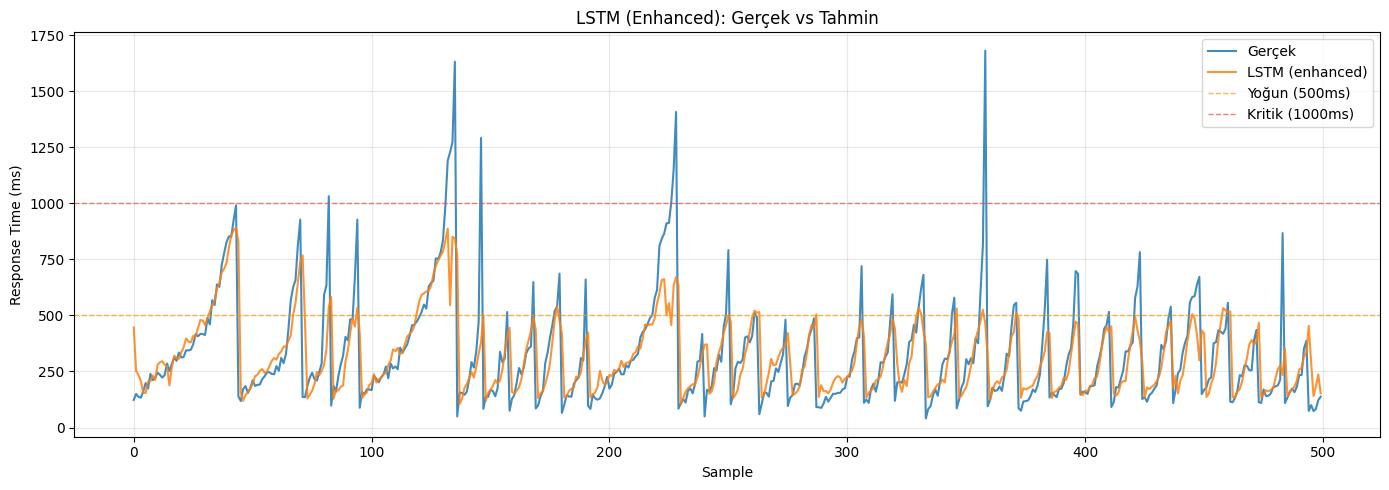

In [13]:
plt.figure(figsize=(14, 5))
n = 500
plt.plot(y_test_orig[:n],  label="Gerçek",         linewidth=1.5, alpha=0.85)
plt.plot(y_pred_lstm[:n],  label="LSTM (enhanced)", linewidth=1.5, alpha=0.85)
plt.axhline(500,  color="#f39c12", linestyle="--", linewidth=1, alpha=0.7, label="Yoğun (500ms)")
plt.axhline(1000, color="#e74c3c", linestyle="--", linewidth=1, alpha=0.7, label="Kritik (1000ms)")
plt.title("LSTM (Enhanced): Gerçek vs Tahmin")
plt.xlabel("Sample")
plt.ylabel("Response Time (ms)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/lstm_enhanced_predictions.png", dpi=150, bbox_inches='tight')
plt.show()

## Model Kaydetme

In [14]:
models_path = "../models"
os.makedirs(models_path, exist_ok=True)
os.makedirs("../outputs", exist_ok=True)

model.save(os.path.join(models_path, "lstm_enhanced_model.keras"))
joblib.dump(scaler_X, os.path.join(models_path, "scaler_X_enhanced.pkl"))
joblib.dump(scaler_y, os.path.join(models_path, "scaler_y_enhanced.pkl"))

# 04 notebook için sonuçları kaydet
pd.DataFrame({
    "y_true":      y_test_orig,
    "y_pred_lstm": y_pred_lstm
}).to_csv("../data/lstm_enhanced_test_results.csv", index=False)

# Final karşılaştırma tablosunu kaydet
final_df.to_csv("../data/final_model_comparison.csv")

print("Kaydedildi.")
print("\n--- FINAL SONUÇLAR ---")
print(final_df.to_string())

Kaydedildi.

--- FINAL SONUÇLAR ---
                    MAE    RMSE      R2
Model                                  
LR (baseline)    147.21  196.44  0.0242
RF (baseline)    146.37  196.56  0.0230
LSTM (baseline)  121.23  177.79  0.2008
LR (enhanced)    123.71  178.91  0.1908
RF (enhanced)     88.17  152.82  0.4096
LSTM (enhanced)   88.75  154.16  0.3992
